In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import fetch_california_housing


In [3]:
housing= fetch_california_housing()


In [4]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [5]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [6]:
print(housing.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [7]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Preparing the dataset


In [8]:
dataset= pd.DataFrame(housing.data,columns= housing.feature_names)

In [9]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
##i want to add my target dependent variable , which i ll be working for the output for
## to the dataset
dataset["Price"]=housing.target

In [11]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [13]:
##summarizing the stats of the data
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [14]:
##wheever you get the dataset yo have to chcek the missing values
dataset.isnull().sum()
##.sum function is applied to give the aggregate of all and then it gives zero showing no missing values


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

EXPLORATORY DATA ANALYSIS


In [15]:
## 1) To study and get about correlation
## there are two types of correlation we should be dealing with , multi correaltion and secind is corelation of independent variables with the
dataset.corr()
#here we are seeing pearson correlation between two x and y values which sees whether two values are highly positively correlated or negativel correlated por not at all correlated

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


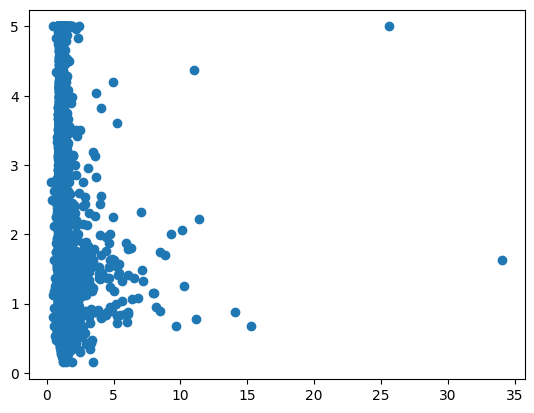

In [16]:
plt.scatter(dataset["AveBedrms"],dataset["Price"])

Text(0, 0.5, 'Price')

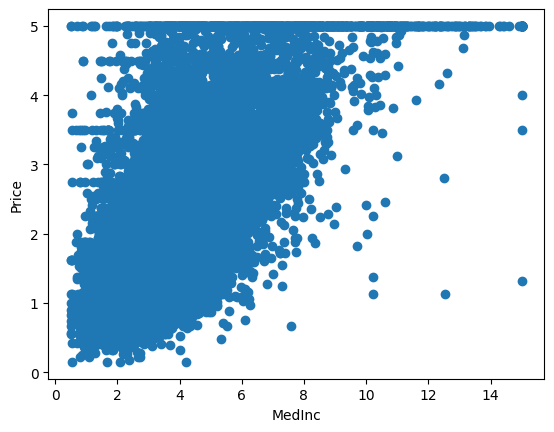

In [17]:
plt.scatter(dataset["MedInc"],dataset["Price"])
plt.xlabel("MedInc")
plt.ylabel("Price")

<AxesSubplot:xlabel='MedInc', ylabel='Price'>

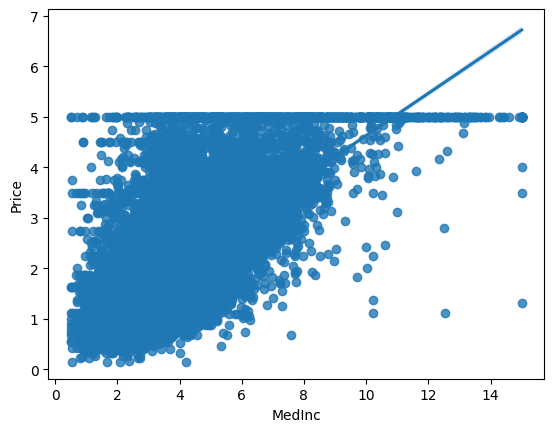

In [20]:
##if we have one independent featiure and one our price
 ##then here we are trying the regression plot
import seaborn as sns
sns.regplot(x="MedInc",y="Price",data=dataset)

<AxesSubplot:xlabel='HouseAge', ylabel='Price'>

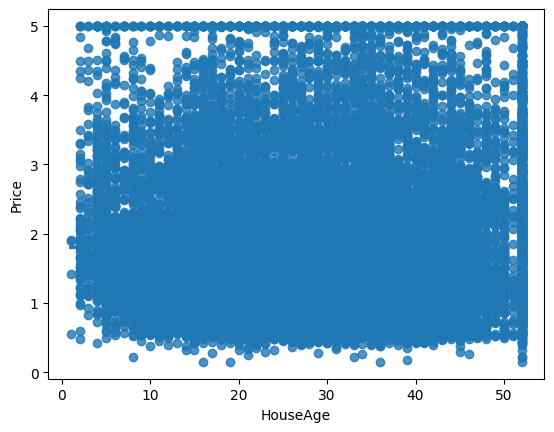

In [21]:

sns.regplot(x="HouseAge",y="Price",data=dataset)

<Axes: xlabel='Population', ylabel='Price'>

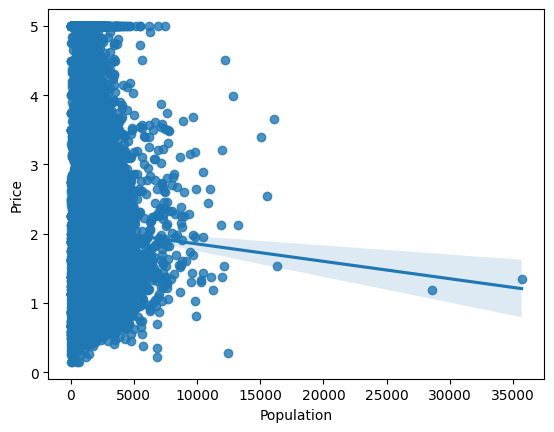

In [ ]:

sns.regplot(x="Population",y="Price",data=dataset)

In [22]:
##now we are dealing with dependent and independent  features
#thw price here is the only dependent feature and all other are termed to be as independent features
x = dataset.iloc[:,:-1] #it gives all theindependent columns except the last one
print(x)
y = dataset.iloc[:,-1] # it gives me all the datset points
print(y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

TRAIN , TEST SPLIT


In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size= 0.3,random_state=42)

In [24]:
x_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
18474,3.8788,20.0,5.140069,1.060850,2656.0,3.049369,37.13,-121.66
1203,2.3243,27.0,6.347188,1.063570,1100.0,2.689487,39.38,-121.74
6413,6.5722,34.0,6.194323,1.004367,1344.0,2.934498,34.11,-118.03
17074,2.9286,20.0,2.337963,1.000000,326.0,1.509259,37.48,-122.21
616,3.9500,52.0,6.060870,0.969565,545.0,2.369565,37.74,-122.15
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [25]:
x_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
3161,1.7656,26.0,4.149367,0.891139,1222.0,3.093671,35.23,-118.85
2630,1.6528,32.0,4.544776,1.235075,620.0,2.313433,40.75,-124.21
18443,5.1663,25.0,6.186154,0.975385,2178.0,3.350769,37.25,-121.82
3174,3.1406,41.0,5.691781,1.020548,443.0,3.034247,36.37,-119.78


In [ ]:
y_train

,Price
18474,2.269
1203,0.855
6413,4.374
17074,2.375
616,2.190
...,...
11284,2.292
11964,0.978
5390,2.221
860,2.835


In [26]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
3161     0.68000
2630     0.58100
18443    2.41200
3174     1.00000
2565     1.04200
Name: Price, Length: 14448, dtype: float64

**STANDARD SCALING **
in liner regression we use gradient descent , one imp thing is that , our main aim is to come near the global minima , so every feature we see in here is being calculated wrt diffrent diff units , but we need to standarize all the data points to the same scale , means we need to normalize it


In [27]:
## important step : standarising the dataset
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [28]:
x_train = scaler.fit_transform(x_train)

In [29]:
x_test=scaler.transform(x_test)

In [30]:
import pickle
pickle.dump(scaler,open("scaler.pkl","wb"))

In [ ]:
x_train

array([[ 0.00507757, -0.68034979, -0.11374753, ...,  0.00623844,
         0.68007978, -1.02757745],
       [-0.80842225, -0.12221444,  0.30502551, ..., -0.04990604,
         1.72947124, -1.06734743],
       [ 1.41458571,  0.43592091,  0.25199365, ..., -0.01168232,
        -0.72843675,  0.77698546],
       ...,
       [-0.48914516,  0.59538816, -0.51386749, ...,  0.05034187,
        -0.76574845,  0.60299179],
       [ 0.96819436, -1.0790179 ,  0.32173334, ...,  0.02644496,
         0.88995807, -1.17671488],
       [-0.67696445,  1.87112611, -0.71651721, ..., -0.14051408,
         0.97857335, -1.40539227]])

In [ ]:
x_test

array([[-1.14496888, -0.28168168, -0.44258136, ...,  0.1354238 ,
         0.18103584,  0.28980319],
       [-0.70009516,  0.11698643, -0.14867721, ..., -0.05141807,
        -0.24804866,  0.06609704],
       [-0.20356983,  1.87112611, -0.51718492, ..., -0.25726476,
         0.99256524, -1.41533477],
       ...,
       [ 0.67885114, -0.28168168,  0.24915956, ...,  0.05325936,
         0.73604733, -1.10711741],
       [-0.38123672,  0.99405627,  0.077652  , ...,  0.00387929,
         0.32561867, -0.09298288],
       [-0.36527549,  0.99405627,  0.21738245, ..., -0.06225741,
         2.38242592, -2.26541812]])

MODEL TRAINING


In [ ]:
# importing the model
from sklearn.linear_model import LinearRegression


In [ ]:
regression = LinearRegression()

In [ ]:
regression.fit(x_train,y_train)

LinearRegression()

In [ ]:
#since we have quite alot of parameters , the plane is not be 3d plane but a hyper plane that we are going to generate
#whenever we create a regression plane two imp tings are there coefficient and the intercept
##print the coefficent and the intercept
print(regression.coef_)
#and this will equal to the number of independent feature coz every indipendent feature
#i will be havinga coefficient

[ 0.83244449  0.12395663 -0.29622539  0.3692488   0.00667973 -0.0200085
 -0.88505102 -0.85504875]


In [ ]:
print(regression .intercept_)

2.0610750597545286


In [ ]:
###prediction with test data
reg_pred=regression.predict(x_test)

In [ ]:
reg_pred

array([0.73493543, 1.76473379, 2.6706274 , ..., 2.72433268, 1.57008971,
       1.58683361])

In [ ]:
#in order to see we are getting the correct prediction , x can be comapred to y , coz for x_test values , the y_test is true


ASSUMPTIONS


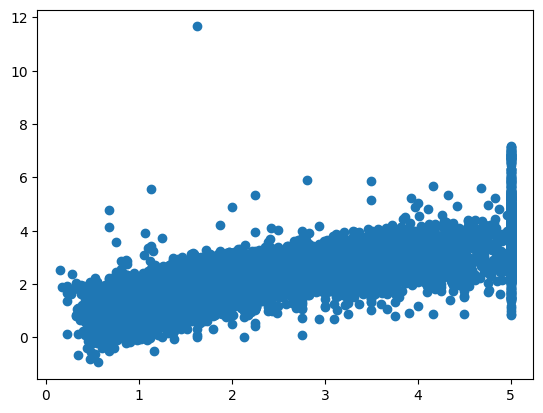

In [ ]:
##Ploting the scatter plot to check that the prediction is correct
plt.scatter(y_test, reg_pred)

In [ ]:
#from this scatter plot we can see the values to be linear and hence yes the model has performed well, reg_pred
#is the predicyion value and wrt that y_test values rae true values and when we see their graph is linear then model has done well

In [ ]:
#residual ? ->residual is nothing but the error wrt the ytest and reg_pred
residuals = y_test- reg_pred
residuals

,Price
20046,-0.257935
3024,-1.306734
15663,2.329383
20484,-0.647514
9814,0.182844
...,...
3161,-0.289119
2630,-0.600227
18443,-0.312333
3174,-0.570090


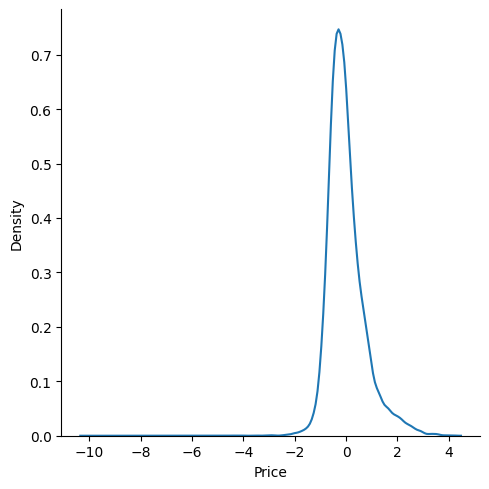

In [ ]:
#plotting this residuals, particulary going to use seaborn
sns.displot(residuals,kind="kde")
#whenever i ll be doing this displot grpah wrt to residual , we must be getting normal distribution ,
#in here it shows that maximum error occurs btween -2, 2 , this is what we ifer and if it is distorted line in the curve then it means there are outliers there
#but as we can see we are getting the bell curve in here , i.e the normal curve hence our model is doing best


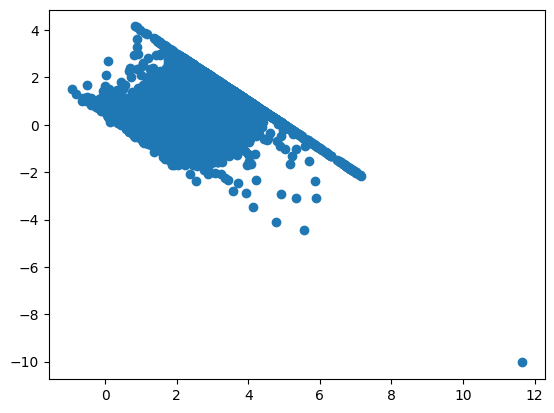

In [ ]:
##scatter plot wrt to prediction and residuals
##uniform ditribution
plt.scatter(reg_pred,residuals)
#residual plot should have random distribution , inhere we ae not getting that , may be our data requires some other model , but lets just proceed with thus now



In [ ]:
#to be sure , about how exactly our model is performing , we must be using performance matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test,reg_pred))
print(mean_squared_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))
# all these values will show the model performance
#The MAE of 0.53 indicates the model predictions deviate by around $53,000 on average.
#The RMSE of 0.72 shows some larger prediction errors are present, likely due to outliers and nonlinear relationships in the California Housing dataset.
#Since the dataset contains capped target values, the residual plot naturally forms a triangular pattern.


0.5297046535630141
0.5275236518754022
0.7263082347567059


In [ ]:
# R square and adjusted R square -> this is also a performance matrix
# r^2 = 1 - (sum of square residual)/(sum of square total)
# adjusted r^2 = 1 - [(1-r^2)*(n-1)/(n-k-1)] , n -> no. of observations, k ->no. of predictor values
#adjusted r^2 is always lessthan r^2
# whatever score we are getting the more it is towards one the more it is better

from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.6031107469263566


In [ ]:
  # now inplementing ajusted r^2 , for that there is no particular library , so we will be
  # implying the formula directly
  1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

  # got the adjusted r2 less than r2 but not major difference we got in here


0.6028908484552304

SO NOW THE REGRESSION MODEL WE HAVE CREATED , WE WILL BE TAKING NEW DATA AND RUNNING THE MODEL TO SEE THAT HOW IT IS BEHAVING AND WHAT OUTPUT WE WILL GET  

#NEW DATA PREDICTION

In [ ]:
#in here we have trained the model over the bulk data directly from running regression.predict but then ,
#mostly we het datapoints to work upon instaed of a 2D bulk data
#how we will be working over that is that :
housing.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [ ]:
#what did we see above is that this data is scattered for like large number of rows and columns
# for taking each point with seperatability , like for the 0 list among this 2d array list
#we can reshape the data to make it column wise or row wise
housing.data[0].reshape(1,-1)

array([[   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]])

In [ ]:
scaler.transform(housing.data[0].reshape(1,-1))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 2.3319644 ,  0.99405627,  0.52599186, -0.15468739, -0.94890699,
        -0.07080035,  1.02987693, -1.31093857]])

In [ ]:
#now if we see its shape what we get is that 1 row then 8 columns it shifted
housing.data[0].reshape(1,-1).shape
#this is how we have to give the data for the model prediction

(1, 8)

In [ ]:
regression.predict(scaler.transform(housing.data[0].reshape(1,-1)))
# this results shows the value what the model will predict with this dataset

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.11709649])

##BUT BUT BUT , whenever we aree getting a new data , we need to do standardization as we did while training the model above SO WE DID THAT

##PICKLING THE MODEL FILE FOR DEPLOYMENT

In [ ]:
import pickle

In [ ]:
pickle.dump(regression,open('regmodel.pkl','wb'))
#pickle → Python module for converting objects into a byte stream (serialization).
#dump() → writes the object into a file.
#regression ->This is your trained Linear Regression model object.
#'regmodel.pkl' → filename where model is stored
#'wb' → write binary mode
#Save the trained regression model into a binary file named regmodel.pkl.

In [ ]:
#we can load this file after saving too , in the read byte mode using the pickle library only
pickled_model=pickle.load(open('regmodel.pkl','rb'))

In [ ]:
#just in order to test we get the model , and it is running the same
pickled_model.predict(scaler.transform(housing.data[0].reshape(1,-1)))
# and yes we are getting the same value

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.11709649])